# 3D stratification

Manifolds of different intrinsic dimension in `R^3`. The second
filtration encodes local geometry (intrinsic dimension or tangent
direction). Euclidean distance alone cannot


In [1]:
from pathlib import Path                                                                                                                                                                                            

import numpy as np                                                                                                                                                                                                  
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll                                                                                                                                                                        

from mpc.experiment_utils import align_hungarian                                                                                                                                                                    
from mpc.filtration_builder import FiltrationBuilder
from mpc.pipeline import evaluate_all, run_bifiltration, run_standard_baselines                                                                                                                                     

FIG = Path("figures")                                                                                                                                                                                               
FIG.mkdir(exist_ok=True)

In [2]:
def sphere_plus_lines(n_sphere=150, n_line=60, seed=42):
    rng = np.random.RandomState(seed)
    th = rng.uniform(0, 2 * np.pi, n_sphere)
    ph = np.arccos(rng.uniform(-1, 1, n_sphere))
    sph = np.column_stack([np.sin(ph)*np.cos(th), np.sin(ph)*np.sin(th), np.cos(ph)])
    def chord(ax, ay, n):
        m = np.sqrt(max(0.0, 1 - ax*ax - ay*ay))
        z = np.linspace(-m, m, n)
        return np.column_stack([np.full(n, ax), np.full(n, ay), z])
    X = np.vstack([sph, chord(0.2, 0.3, n_line), chord(-0.3, 0.1, n_line)])
    y = np.r_[np.zeros(n_sphere), np.ones(n_line), 2 * np.ones(n_line)].astype(int)
    return X, y

def swiss_roll_plus_line(n_roll=300, n_line=60, seed=0):
    X_roll, _ = make_swiss_roll(n_samples=n_roll, noise=0.05, random_state=seed)
    X_roll = X_roll / 15.0
    t = np.linspace(-1.0, 1.0, n_line)
    line = np.column_stack([t, np.full(n_line, 0.5), np.zeros(n_line)])
    X = np.vstack([X_roll, line])
    y = np.r_[np.zeros(n_roll), np.ones(n_line)].astype(int)
    return X, y

def torus_plus_line(n_torus=300, n_line=60, seed=0):
    rng = np.random.RandomState(seed)
    u = rng.uniform(0, 2*np.pi, n_torus)
    v = rng.uniform(0, 2*np.pi, n_torus)
    R, r = 1.0, 0.3
    tor = np.column_stack([(R + r*np.cos(v))*np.cos(u),
                           (R + r*np.cos(v))*np.sin(u),
                           r*np.sin(v)])
    t = np.linspace(-0.6, 0.6, n_line)
    line = np.column_stack([np.full(n_line, R - r), np.zeros(n_line), t])
    X = np.vstack([tor, line])
    y = np.r_[np.zeros(n_torus), np.ones(n_line)].astype(int)
    return X, y

In [3]:
def run_ours(X, k):
    fb = FiltrationBuilder(X)
    f1 = fb.get_filtration_from_scipy_dist("euclidean")
    f2 = fb.get_filtration_from_intrinsic_dim(k_neighbors=5, var_threshold=0.99)
    labels = run_standard_baselines(X, k)
    labels["Ours (Euclid+IntDim)"] = run_bifiltration(
        X, f1, f2, n_clusters=k, method="simplify",
    ).labels_combined
    return labels

DATASETS = [
    ("Sphere + 2 lines", *sphere_plus_lines(), 3),
    ("Swiss roll + line", *swiss_roll_plus_line(), 2),
    ("Torus + line", *torus_plus_line(), 2),
]
runs = [(name, X, y, k, run_ours(X, k)) for name, X, y, k in DATASETS]

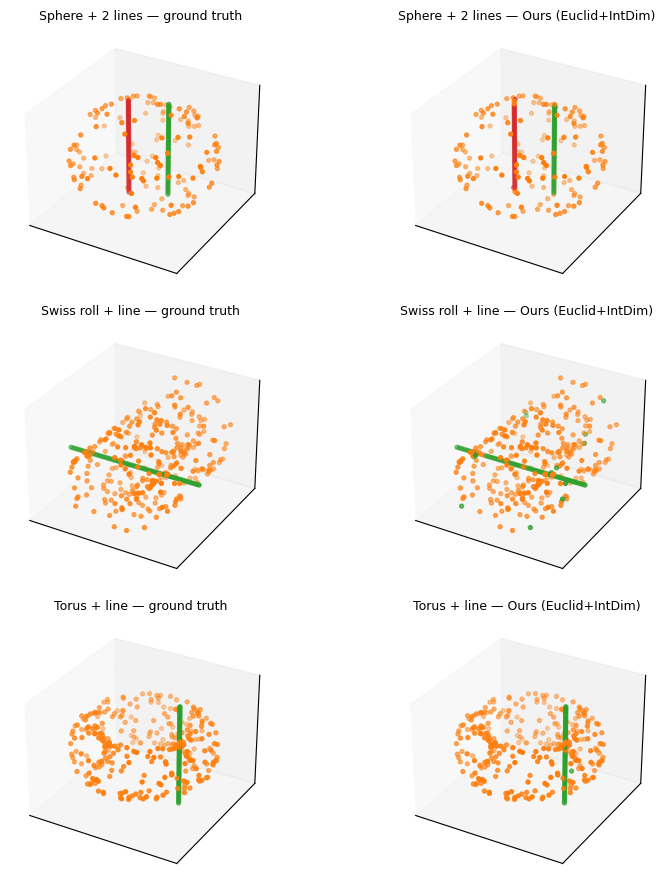

In [4]:
fig = plt.figure(figsize=(9, 9))
for row, (name, X, y, k, labels) in enumerate(runs):
    pred_al, y_norm = align_hungarian(labels["Ours (Euclid+IntDim)"], y)
    for col, (lab, tag) in enumerate([(y_norm, "ground truth"),
                                      (pred_al, "Ours (Euclid+IntDim)")]):
        ax = fig.add_subplot(3, 2, 2*row + col + 1, projection="3d")
        ax.scatter(X[:, 0], X[:, 1], X[:, 2],
                   c=lab, cmap="tab10", vmin=0, vmax=9, s=8)
        ax.set_title(f"{name} — {tag}", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
fig.tight_layout()
fig.savefig(FIG / "strat3d.png", dpi=150, bbox_inches="tight")
plt.show()